# Exploratory Data Analysis (EDA)
## Customer Churn Prediction

This notebook explores the Telco Customer Churn dataset to understand customer behavior and identify key drivers of churn.


In [ ]:
import pandas as pd        # for data tables
import numpy as np         # for numbers
import matplotlib.pyplot as plt  # basic plots
import seaborn as sns      # nicer plots

Matplotlib is building the font cache; this may take a moment.


In [ ]:
df = pd.read_csv("../data/raw/telco_churn.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.shape

(7043, 33)

The dataset contains 7,043 customer records and 33 features describing demographics, services, and billing information.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

The dataset contains a large number of categorical features stored as object types, which will require encoding before modeling. Some fields such as Churn Reason contain missing values because they apply only to churned customers.

### Target Variable

The target variable for this project is **Churn**, which indicates whether a customer has left the service. The original dataset provides the target as **Churn Value (0/1)**. For consistency, it is renamed to **Churn** for the remainder of the notebook.

In [13]:
df["Churn Value"].value_counts(normalize=True) * 100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [15]:
# Rename target column for consistency in modeling
df.rename(columns={"Churn Value": "Churn"}, inplace=True)

In [19]:
# Clean numeric column: Total Charges (often stored as text)
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

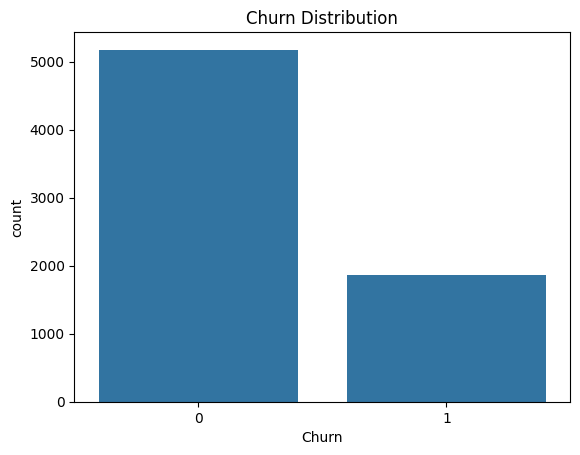

In [ ]:
df["Churn"].value_counts()

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

Approximately 26.5% of customers have churned, indicating a moderately imbalanced classification problem where churned customers represent a smaller but significant portion of the dataset.

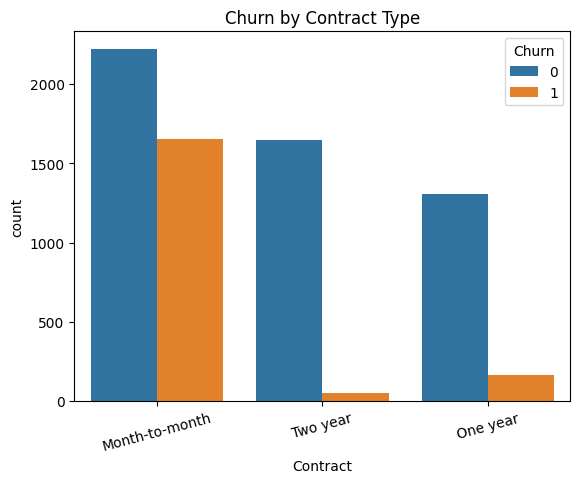

In [17]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

Customers on month-to-month contracts exhibit significantly higher churn compared to customers on one-year or two-year contracts, indicating that contract length is a strong predictor of churn.

## Key Drivers of Churn

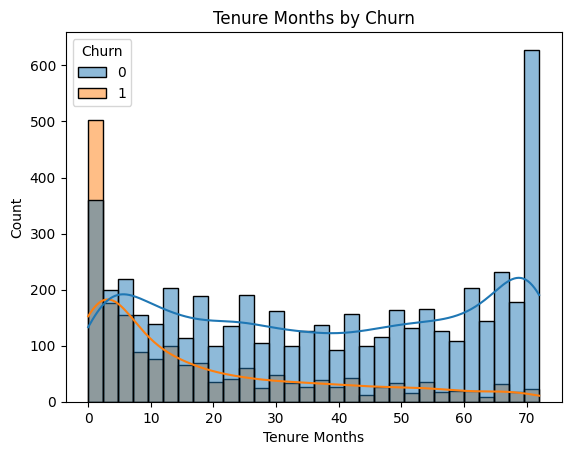

In [20]:
sns.histplot(data=df, x="Tenure Months", hue="Churn", bins=30, kde=True)
plt.title("Tenure Months by Churn")
plt.show()

Customers with shorter tenure are more likely to churn, suggesting churn risk is highest early in the customer lifecycle.

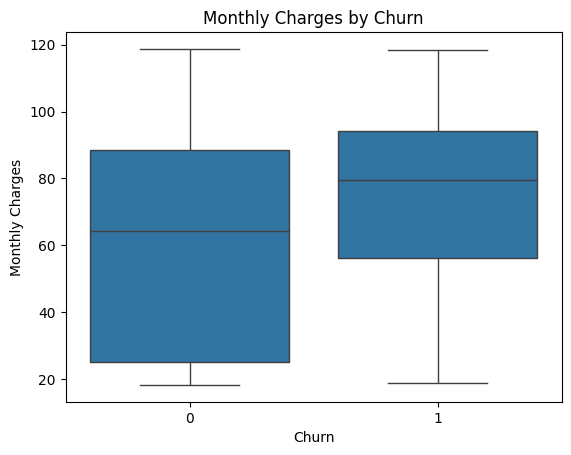

In [21]:
sns.boxplot(x="Churn", y="Monthly Charges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

Churned customers tend to have higher monthly charges, indicating potential price sensitivity among customers who leave.

## EDA Summary
EDA suggests Contract type, Tenure Months, and Monthly Charges are key churn drivers. The target variable was standardized to `Churn` (0/1), and `Total Charges` was cleaned for numeric modeling. The cleaned dataset is saved for the modeling notebook.


In [23]:
df.to_csv("../data/processed/churn_clean.csv", index=False)